In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



In [2]:
%pip install torchmetrics
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.3 MB/s eta 0:00:00


In [3]:
#are we in collab?
from pathlib import Path
import torch
from catboost import CatBoostClassifier
from google.colab import drive

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ModuleNotFoundError:
    pass

if IN_COLAB:
    drive.mount("/content/drive")
    path_to_matches      = Path("/content/drive/MyDrive/COMP4630/Final/matches.csv")
    path_to_characters   = Path("/content/drive/MyDrive/COMP4630/Final/processed_summoner_data.csv")
    path_to_champion_tbl = Path("/content/drive/MyDrive/COMP4630/Final/ChampionTbl.csv")
    path_to_intervals    = Path("/content/drive/MyDrive/COMP4630/Final/intervals.csv")
else:
    path_to_matches      = Path("matches.csv")
    path_to_characters   = Path("processed_summoner_data.csv")
    path_to_champion_tbl = Path("ChampionTbl.csv")
    path_to_intervals    = Path("intervals.csv")

if torch.cuda.is_available():
    device = "cuda"
    print("GPU available!")
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Mounted at /content/drive
GPU available!
Using device: cuda


In [4]:
# load your selected dataset and look at it

if device == "cpu":
  characters = pd.read_csv("processed_summoner_data.csv")
  match_info = pd.read_csv("matches.csv")
  champion_ids = pd.read_csv("ChampionTbl.csv")
  intervals = pd.read_csv("intervals.csv")
else:
  characters  = pd.read_csv(path_to_characters)
  match_info  = pd.read_csv(path_to_matches)
  champion_ids = pd.read_csv(path_to_champion_tbl)
  intervals = pd.read_csv(path_to_intervals)
characters.info()
match_info.info()
champion_ids.info()
intervals.info()
# we can see we have some invalid role data, and individual position data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399540 entries, 0 to 399539
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   id                   399540 non-null  int64 
 1   match_id             399540 non-null  object
 2   participant_id       399540 non-null  int64 
 3   team_id              399540 non-null  int64 
 4   champion             399540 non-null  object
 5   role                 399477 non-null  object
 6   individual_position  399539 non-null  object
dtypes: int64(3), object(4)
memory usage: 21.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39954 entries, 0 to 39953
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   match_id       39954 non-null  object
 1   game_duration  39954 non-null  int64 
 2   patch_version  39954 non-null  int64 
 3   winning_team   39954 non-null  int64 
 4   game_date      39

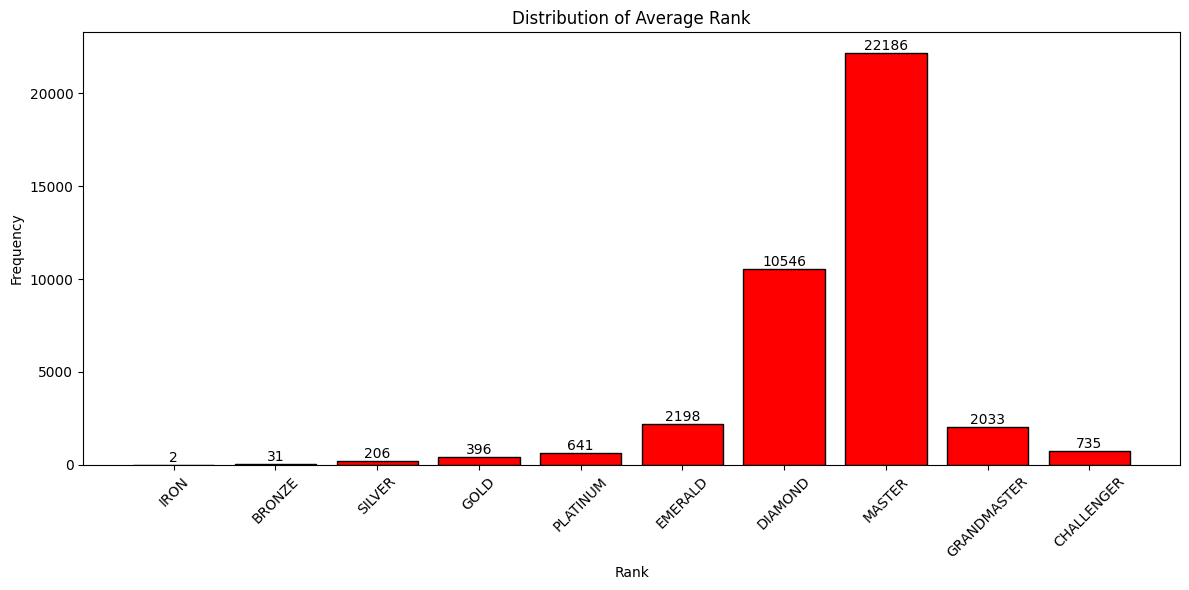

In [5]:
#visualize rank distributions
rank_order = [
    'IRON', 'BRONZE', 'SILVER', 'GOLD', 'PLATINUM',
    'EMERALD', 'DIAMOND', 'MASTER', 'GRANDMASTER', 'CHALLENGER'
]

rank_counts = match_info['average_rank'].value_counts()
rank_counts = rank_counts.reindex(rank_order, fill_value=0)

plt.figure(figsize=(12, 6))
bars = plt.bar(rank_counts.index, rank_counts.values, color='red', edgecolor='black')

for bar in bars:
    count = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, count,
             str(int(count)), ha='center', va='bottom', fontsize=10)

plt.title('Distribution of Average Rank')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

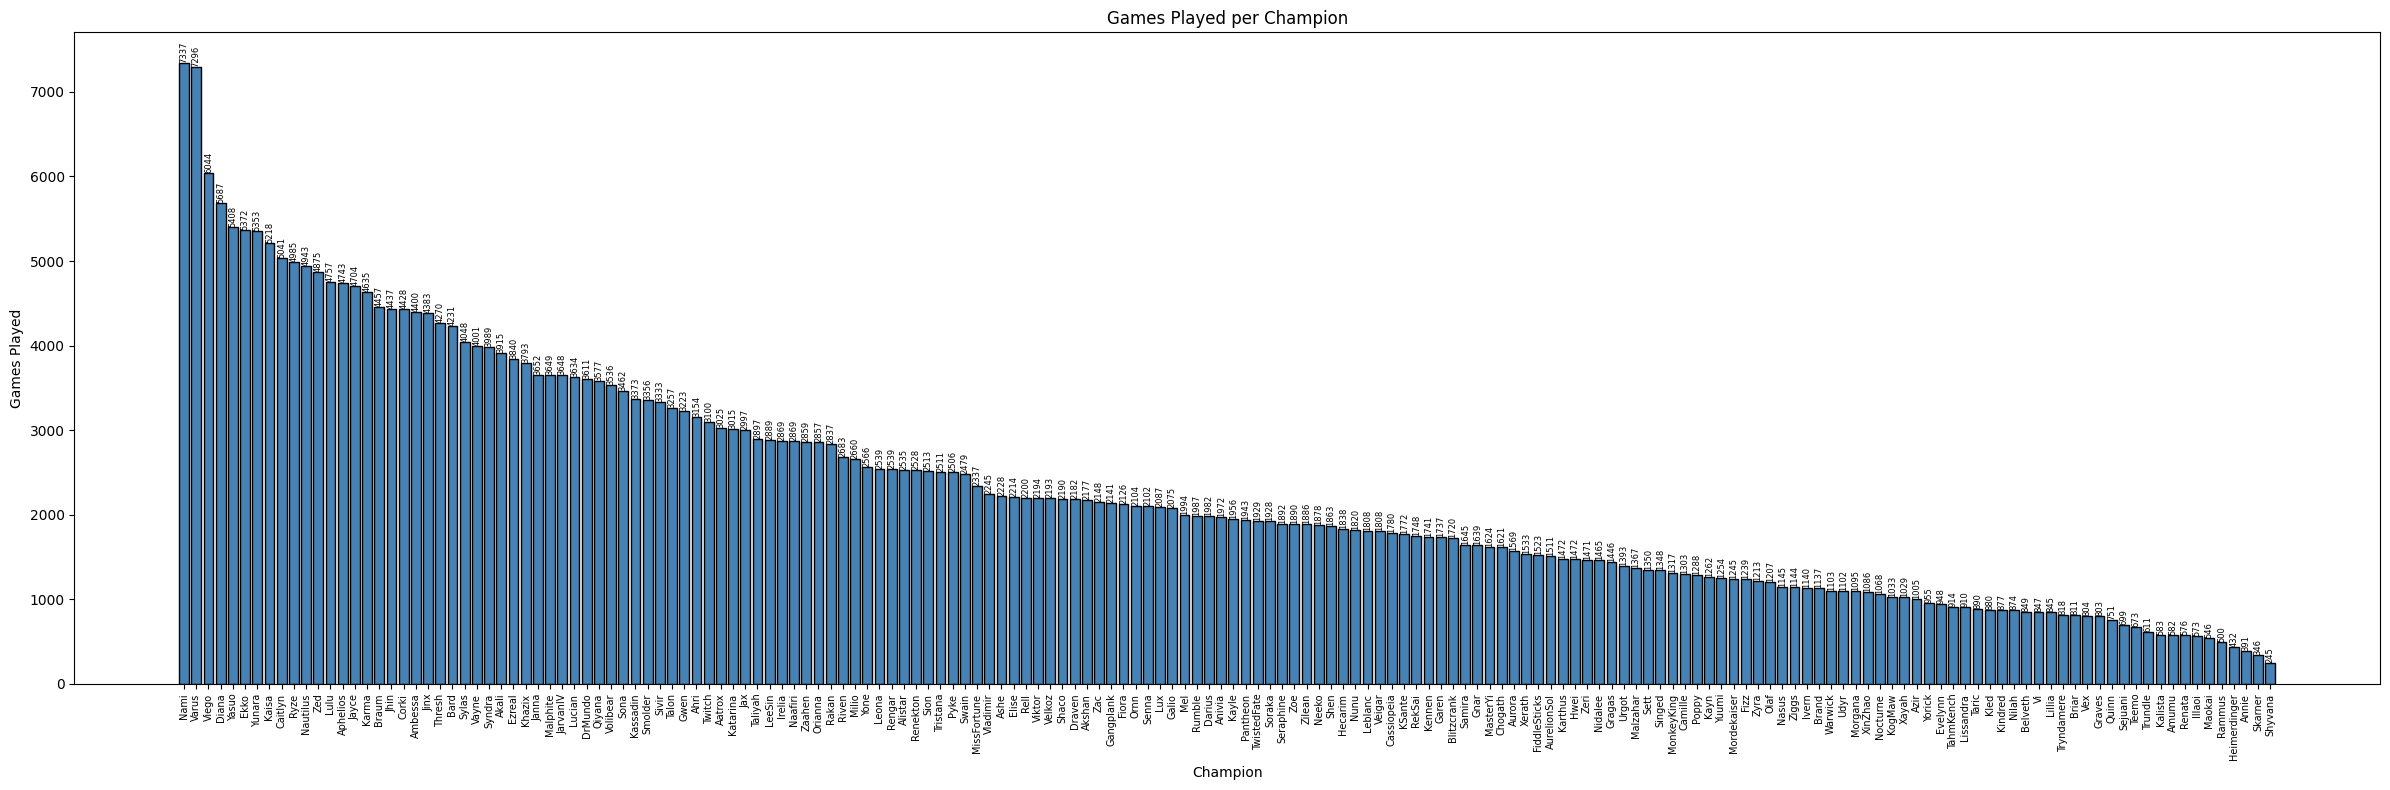

In [6]:
#visualize champion pick rates
champ_counts = characters['champion'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(24, 8))
bars = plt.bar(champ_counts.index, champ_counts.values, color='steelblue', edgecolor='black')

for bar in bars:
    count = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, count,
             str(int(count)), ha='center', va='bottom', fontsize=6, rotation=90)

plt.title('Games Played per Champion')
plt.xlabel('Champion')
plt.ylabel('Games Played')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [7]:
# Merge the intervals, matches, and characters (summoner data) csv's

df = intervals.merge(
    characters,
    left_on="player_id",
    right_on="id",
    suffixes=("", "_drop")
)

df = df.merge(
    match_info,
    on="match_id",
    suffixes=("", "_match_drop")
)

df = df.loc[:, ~df.columns.str.contains("_drop")]

print(f"Joined {len(df)} rows.")
print(df.columns.tolist())
df.head()

Joined 2108090 rows.
['id', 'match_id', 'player_id', 'minute', 'current_gold', 'total_gold', 'cs', 'jungle_cs', 'xp', 'level', 'kills', 'deaths', 'assists', 'item_0', 'item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'team_kills', 'team_inhibitors', 'team_towers', 'team_dragons_fire', 'team_dragons_water', 'team_dragons_earth', 'team_dragons_air', 'team_dragons_chemtech', 'team_dragons_hextech', 'team_dragons', 'team_barons', 'team_void_grubs', 'team_heralds', 'gold_diff', 'xp_diff', 'team_gold_diff', 'participant_id', 'team_id', 'champion', 'role', 'individual_position', 'game_duration', 'patch_version', 'winning_team', 'game_date', 'game_version', 'game_mode', 'queue_id', 'region', 'average_rank', 'blue_bans', 'red_bans']


,id,match_id,player_id,minute,current_gold,total_gold,cs,jungle_cs,xp,level,...,patch_version,winning_team,game_date,game_version,game_mode,queue_id,region,average_rank,blue_bans,red_bans
0,1,EUW1_7688004322,1,5,487,1587,33,0,2382,5,...,16,200,2026-01-16 18:15:27,16.1.737.4870,CLASSIC,420,euw1,GOLD,"90,143,54,902,131","51,119,235,35,17"
1,2,EUW1_7688004322,2,5,310,1710,1,30,1589,4,...,16,200,2026-01-16 18:15:27,16.1.737.4870,CLASSIC,420,euw1,GOLD,"90,143,54,902,131","51,119,235,35,17"
2,3,EUW1_7688004322,3,5,384,1684,40,0,2258,5,...,16,200,2026-01-16 18:15:27,16.1.737.4870,CLASSIC,420,euw1,GOLD,"90,143,54,902,131","51,119,235,35,17"
3,4,EUW1_7688004322,4,5,468,1368,20,0,1399,4,...,16,200,2026-01-16 18:15:27,16.1.737.4870,CLASSIC,420,euw1,GOLD,"90,143,54,902,131","51,119,235,35,17"
4,5,EUW1_7688004322,5,5,338,1313,4,0,1220,4,...,16,200,2026-01-16 18:15:27,16.1.737.4870,CLASSIC,420,euw1,GOLD,"90,143,54,902,131","51,119,235,35,17"


In [8]:
# Keep only the first 15 minutes of each match
df_early = df[df["minute"].isin([5, 10, 15, 20, 25])].copy()

print(df_early.shape)
df_early[["match_id", "player_id", "minute", "team_gold_diff", "gold_diff", "xp_diff"]].head(20)




(1847270, 52)


,match_id,player_id,minute,team_gold_diff,gold_diff,xp_diff
0,EUW1_7688004322,1,5,-1274,-182,0
1,EUW1_7688004322,2,5,-1274,-389,-309
2,EUW1_7688004322,3,5,-1274,-475,-150
3,EUW1_7688004322,4,5,-1274,-276,-243
4,EUW1_7688004322,5,5,-1274,48,-17
5,EUW1_7688004322,6,5,1274,182,0
6,EUW1_7688004322,7,5,1274,389,309
7,EUW1_7688004322,8,5,1274,475,150
8,EUW1_7688004322,9,5,1274,276,243
9,EUW1_7688004322,10,5,1274,-48,17


In [9]:
# Aggregate team stats for each 5-minute interval separately
from sklearn.model_selection import train_test_split

interval_data = {}

for minute in [5, 10, 15, 20, 25]:
    df_interval = df[df["minute"] == minute].copy()

    team_interval = (
        df_interval.groupby(["match_id", "team_id", "winning_team"], as_index=False)
        .agg(
            team_gold_diff=("team_gold_diff", "first"),
            gold_diff_sum=("gold_diff", "sum"),
            xp_diff_sum=("xp_diff", "sum"),
            team_towers=("team_towers", "first"),
            team_dragons=("team_dragons", "first"),
            team_barons=("team_barons", "first"),
            team_void_grubs=("team_void_grubs", "first"),
            team_heralds=("team_heralds", "first"),
            team_inhibitors=("team_inhibitors", "first"),
            team_kills=("team_kills", "first")
        )
    )
    interval_data[minute] = team_interval
    print(f"Minute {minute}: {team_interval.shape}")

Minute 5: (79024, 13)
Minute 10: (78770, 13)
Minute 15: (78530, 13)
Minute 20: (72432, 13)
Minute 25: (60698, 13)


In [10]:
# Build features and labels, split by match_id to avoid leakage
splits = {}

for minute, team_interval in interval_data.items():
    X = team_interval.drop(columns=["match_id", "team_id", "winning_team"])
    y = (team_interval["team_id"] == team_interval["winning_team"]).astype(int)

    match_ids = team_interval["match_id"].unique()
    train_ids, test_ids = train_test_split(match_ids, test_size=0.2, random_state=42)
    train_mask = team_interval["match_id"].isin(train_ids)
    test_mask  = team_interval["match_id"].isin(test_ids)

    splits[minute] = {
        "X_train": X[train_mask],
        "X_test":  X[test_mask],
        "y_train": y[train_mask],
        "y_test":  y[test_mask],
        "X":       X
    }
    print(f"Minute {minute} — Train: {train_mask.sum()} rows, Test: {test_mask.sum()} rows")

Minute 5 — Train: 63218 rows, Test: 15806 rows
Minute 10 — Train: 63016 rows, Test: 15754 rows
Minute 15 — Train: 62824 rows, Test: 15706 rows
Minute 20 — Train: 57944 rows, Test: 14488 rows
Minute 25 — Train: 48558 rows, Test: 12140 rows


In [11]:
# Train a separate CatBoost model for each interval
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier

models = {}

for minute, split in splits.items():
    print(f"\nTraining minute {minute} model...")

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("catboost", CatBoostClassifier(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="Accuracy",
            early_stopping_rounds=30,
            verbose=100,
            random_seed=42
        ))
    ])

    model.fit(split["X_train"], split["y_train"])
    models[minute] = model


Training minute 5 model...
0:	learn: 0.6200291	total: 158ms	remaining: 1m 19s
100:	learn: 0.6239362	total: 4.21s	remaining: 16.6s
200:	learn: 0.6255180	total: 7.79s	remaining: 11.6s
300:	learn: 0.6276852	total: 11.8s	remaining: 7.77s
400:	learn: 0.6307223	total: 16.5s	remaining: 4.08s
499:	learn: 0.6318770	total: 17.9s	remaining: 0us

Training minute 10 model...
0:	learn: 0.6914276	total: 27.7ms	remaining: 13.8s
100:	learn: 0.6988384	total: 1.48s	remaining: 5.85s
200:	learn: 0.7004412	total: 2.94s	remaining: 4.37s
300:	learn: 0.7015996	total: 4.44s	remaining: 2.94s
400:	learn: 0.7035673	total: 5.89s	remaining: 1.46s
499:	learn: 0.7047099	total: 7.36s	remaining: 0us

Training minute 15 model...
0:	learn: 0.7473736	total: 15ms	remaining: 7.49s
100:	learn: 0.7534541	total: 2.79s	remaining: 11s
200:	learn: 0.7546957	total: 5.42s	remaining: 8.06s
300:	learn: 0.7562397	total: 6.88s	remaining: 4.54s
400:	learn: 0.7585477	total: 8.4s	remaining: 2.07s
499:	learn: 0.7599643	total: 9.9s	remainin

In [12]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(48558, 10) (12140, 10)



  Minute 5 — Accuracy: 0.6224
              precision    recall  f1-score   support

           0       0.62      0.62      0.62      7903
           1       0.62      0.62      0.62      7903

    accuracy                           0.62     15806
   macro avg       0.62      0.62      0.62     15806
weighted avg       0.62      0.62      0.62     15806



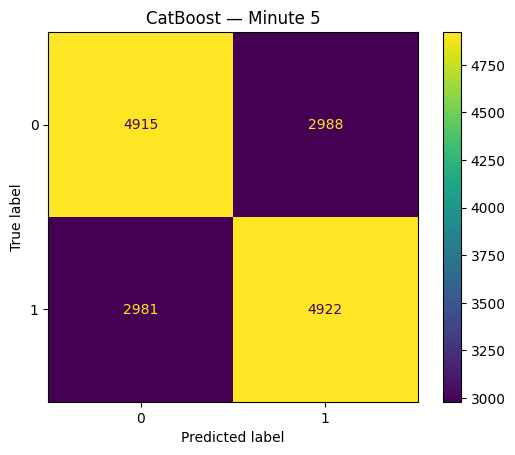


  Minute 10 — Accuracy: 0.6902
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      7877
           1       0.69      0.69      0.69      7877

    accuracy                           0.69     15754
   macro avg       0.69      0.69      0.69     15754
weighted avg       0.69      0.69      0.69     15754



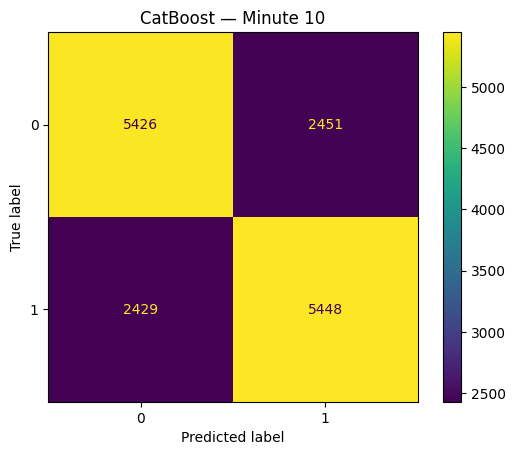


  Minute 15 — Accuracy: 0.7595
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      7853
           1       0.76      0.76      0.76      7853

    accuracy                           0.76     15706
   macro avg       0.76      0.76      0.76     15706
weighted avg       0.76      0.76      0.76     15706



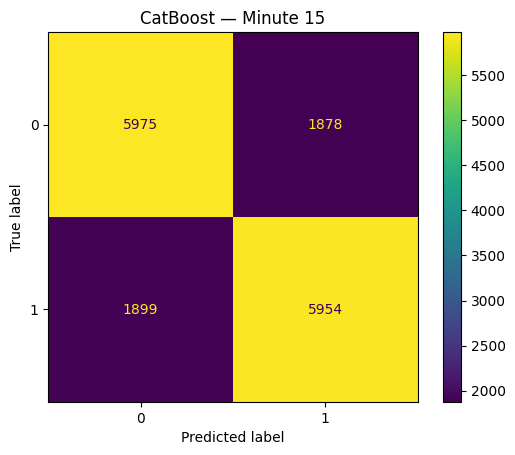


  Minute 20 — Accuracy: 0.7806
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      7244
           1       0.78      0.78      0.78      7244

    accuracy                           0.78     14488
   macro avg       0.78      0.78      0.78     14488
weighted avg       0.78      0.78      0.78     14488



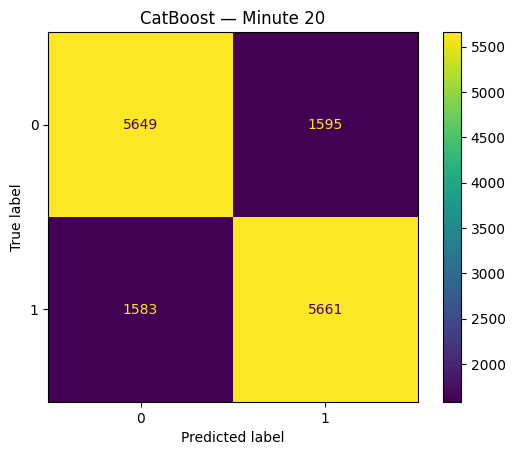


  Minute 25 — Accuracy: 0.8232
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      6070
           1       0.82      0.82      0.82      6070

    accuracy                           0.82     12140
   macro avg       0.82      0.82      0.82     12140
weighted avg       0.82      0.82      0.82     12140



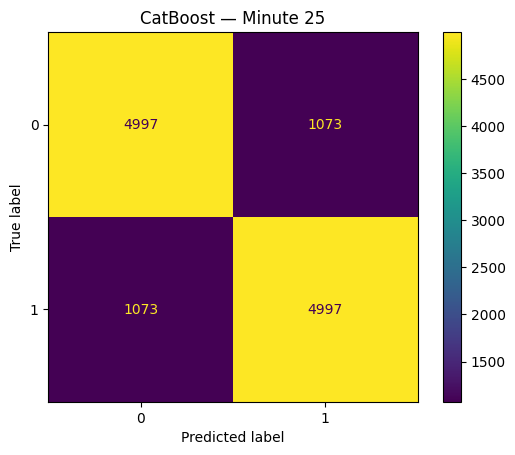

In [13]:
# Evaluate each model
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_summary = {}

for minute, model in models.items():
    split = splits[minute]
    y_pred = model.predict(split["X_test"])
    acc = accuracy_score(split["y_test"], y_pred)
    results_summary[minute] = acc

    print(f"\n{'='*50}")
    print(f"  Minute {minute} — Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(split["y_test"], y_pred))

    ConfusionMatrixDisplay.from_predictions(split["y_test"], y_pred)
    plt.title(f"CatBoost — Minute {minute}")
    plt.show()

In [14]:
# Feature importance for each interval model
import pandas as pd

for minute, model in models.items():
    cat_model = model.named_steps["catboost"]
    imp_df = pd.DataFrame({
        "feature": splits[minute]["X"].columns,
        "importance": cat_model.get_feature_importance()
    }).sort_values("importance", ascending=False)

    print(f"\nMinute {minute} — Feature Importance:")
    print(imp_df.to_string(index=False))


Minute 5 — Feature Importance:
        feature  importance
    xp_diff_sum   35.099917
 team_gold_diff   29.265469
  gold_diff_sum   24.060809
     team_kills   11.573804
   team_dragons    0.000000
    team_towers    0.000000
    team_barons    0.000000
team_void_grubs    0.000000
   team_heralds    0.000000
team_inhibitors    0.000000

Minute 10 — Feature Importance:
        feature  importance
  gold_diff_sum   25.632205
 team_gold_diff   25.182809
    xp_diff_sum   20.218978
   team_dragons   11.272879
     team_kills   10.021703
team_void_grubs    6.342999
    team_towers    1.328427
    team_barons    0.000000
   team_heralds    0.000000
team_inhibitors    0.000000

Minute 15 — Feature Importance:
        feature  importance
 team_gold_diff   28.628021
  gold_diff_sum   22.258906
    xp_diff_sum   21.807041
   team_dragons   12.597612
     team_kills    7.569752
team_void_grubs    3.748956
    team_towers    3.328045
team_inhibitors    0.031933
   team_heralds    0.029733
    te

In [15]:
# Accuracy summary across all intervals
print("Accuracy by interval:")
for minute, acc in results_summary.items():
    print(f"  Minute {minute}: {acc:.4f}")

Accuracy by interval:
  Minute 5: 0.6224
  Minute 10: 0.6902
  Minute 15: 0.7595
  Minute 20: 0.7806
  Minute 25: 0.8232
